In [1]:
import pandas as pd
from pandas import DataFrame,Series
from datetime import datetime
import future
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
sns.set_style('whitegrid')
%matplotlib inline

In [14]:
tech_list = ['TSLA','AMD','NVDA','AAPL','GOOG','MSFT','AMZN']
end = datetime.now()
start = datetime(end.year-3,end.month,end.day)

In [15]:
for stock in tech_list:
    globals()[stock] = yf.download(stock, start=start, end=end)

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [16]:
for stock in tech_list:
    print(f"{stock}: {globals()[stock].shape}")
    print(globals()[stock].head())

TSLA: (751, 5)
Price            Close        High         Low        Open     Volume
Ticker            TSLA        TSLA        TSLA        TSLA       TSLA
Date                                                                 
2023-04-10  184.509995  185.100006  176.110001  179.940002  142154600
2023-04-11  186.789993  189.190002  185.649994  186.690002  115770900
2023-04-12  180.539993  191.580002  180.309998  190.740005  150256300
2023-04-13  185.899994  186.500000  180.940002  182.960007  112933000
2023-04-14  185.000000  186.279999  182.009995  183.949997   96438700
AMD: (751, 5)
Price           Close       High        Low       Open    Volume
Ticker            AMD        AMD        AMD        AMD       AMD
Date                                                            
2023-04-10  95.480003  95.800003  91.019997  91.320000  52536300
2023-04-11  94.029999  96.070000  92.690002  96.059998  51935800
2023-04-12  92.330002  95.000000  91.739998  94.970001  53383100
2023-04-13  92.089996

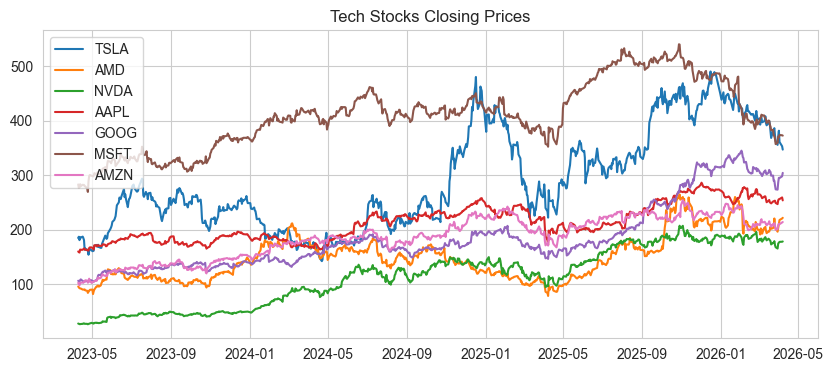

In [17]:
plt.figure(figsize=(10,4))
for stock in tech_list:
    if not globals()[stock].empty:
        plt.plot(globals()[stock].index, globals()[stock]['Close'], label=stock)

plt.legend()
plt.title('Tech Stocks Closing Prices')
plt.show()

In [20]:
ma_day = [5,10,20,50,100]

for ma in ma_day:
    column_name = f"MA for {ma} days"
    AAPL[column_name] = AAPL['Close'].rolling(window=ma).mean()

<Axes: xlabel='Date'>

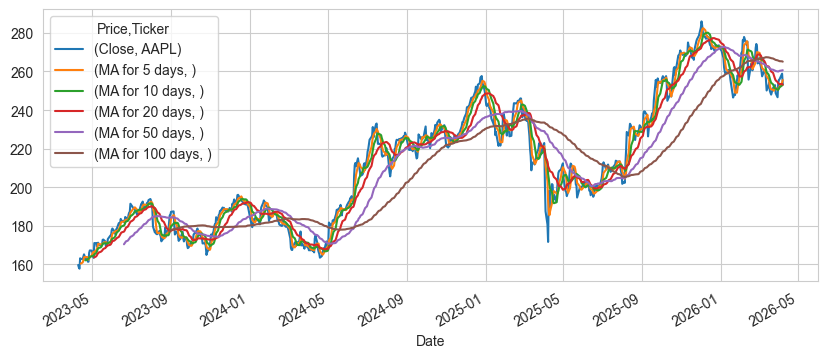

In [23]:
AAPL[['Close'] + [f"MA for {ma} days" for ma in ma_day]].plot(figsize=(10,4))

<Axes: title={'center': 'Daily Return for AAPL'}, xlabel='Date'>

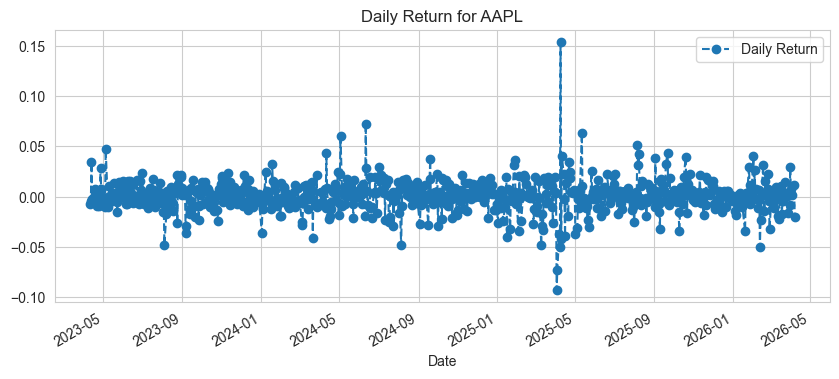

In [24]:
AAPL['Daily Return'] = AAPL['Close'].pct_change()
AAPL['Daily Return'].plot(figsize=(10,4), legend=True, linestyle='--', marker='o', title='Daily Return for AAPL')

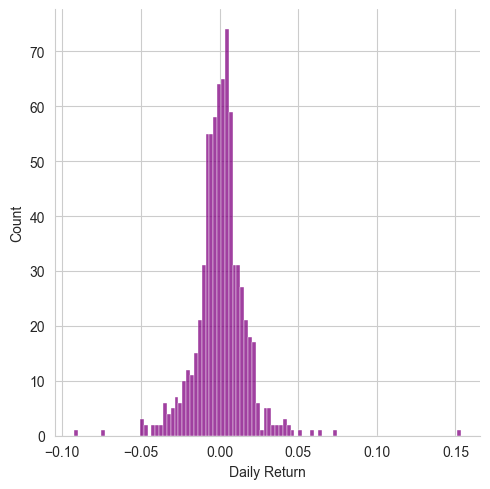

In [27]:
sns.displot(AAPL['Daily Return'].dropna(), bins=100, color='purple')

<Axes: >

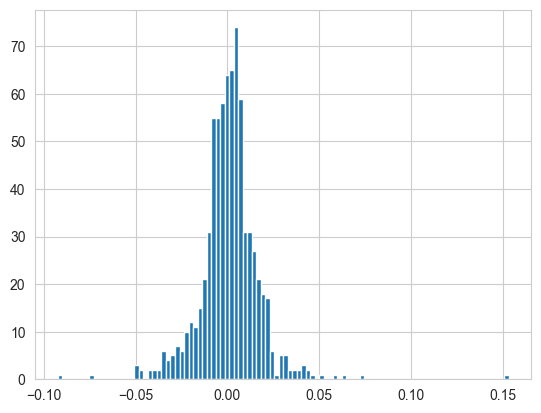

In [28]:
AAPL['Daily Return'].hist(bins=100)

In [30]:
closing_df = yf.download(tech_list, start=start, end=end)['Close']
closing_df.head()

[*********************100%***********************]  7 of 7 completed


Ticker,AAPL,AMD,AMZN,GOOG,MSFT,NVDA,TSLA
Date,,,,,,,
2023-04-10,159.716156,95.480003,102.169998,106.079102,282.695251,27.554607,184.509995
2023-04-11,158.503738,94.029999,99.919998,105.255852,276.286987,27.144970,186.789993
2023-04-12,157.813736,92.330002,97.830002,104.363174,276.931702,26.471565,180.539993
2023-04-13,163.195755,92.089996,102.400002,107.309006,283.134796,26.439592,185.899994
2023-04-14,162.850754,91.750000,102.510002,108.568665,279.520386,26.734335,185.000000


In [32]:
tech_rets = closing_df.pct_change()
tech_rets.head()

Ticker,AAPL,AMD,AMZN,GOOG,MSFT,NVDA,TSLA
Date,,,,,,,
2023-04-10,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-04-11,-0.007591,-0.015186,-0.022022,-0.007761,-0.022668,-0.014866,0.012357
2023-04-12,-0.004353,-0.018079,-0.020917,-0.008481,0.002333,-0.024808,-0.033460
2023-04-13,0.034104,-0.002599,0.046714,0.028227,0.022399,-0.001208,0.029689
2023-04-14,-0.002114,-0.003692,0.001074,0.011739,-0.012766,0.011148,-0.004841


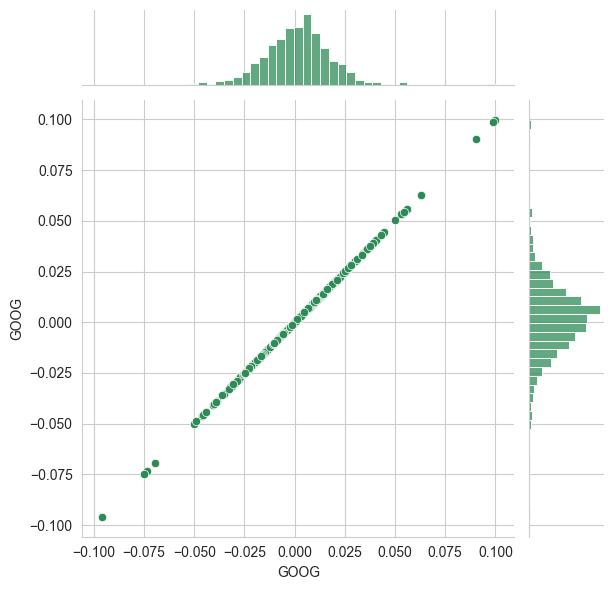

In [34]:
sns.jointplot(x='GOOG', y='GOOG', data=tech_rets, kind='scatter', color='seagreen')

Text(0.05, 0.95, 'Pearson: 0.42')

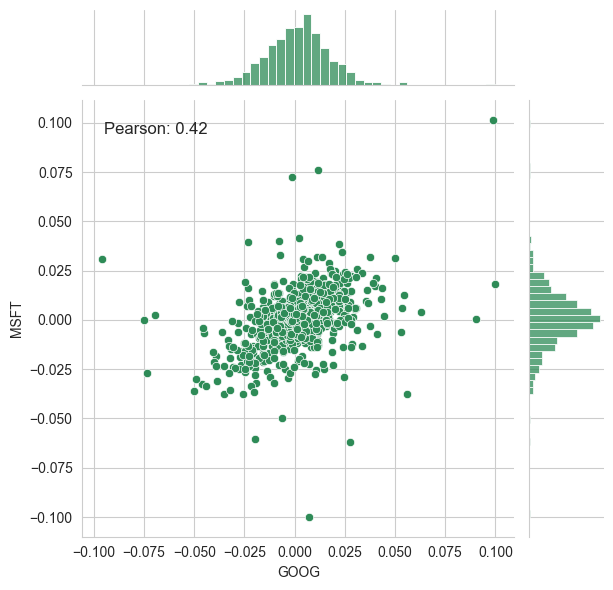

In [36]:
g = sns.jointplot(x='GOOG', y='MSFT', data=tech_rets, kind='scatter', color='seagreen')
corr = tech_rets['GOOG'].corr(tech_rets['MSFT'])
g.ax_joint.text(0.05, 0.95, f'Pearson: {corr:.2f}', transform=g.ax_joint.transAxes, fontsize=12, verticalalignment='top')

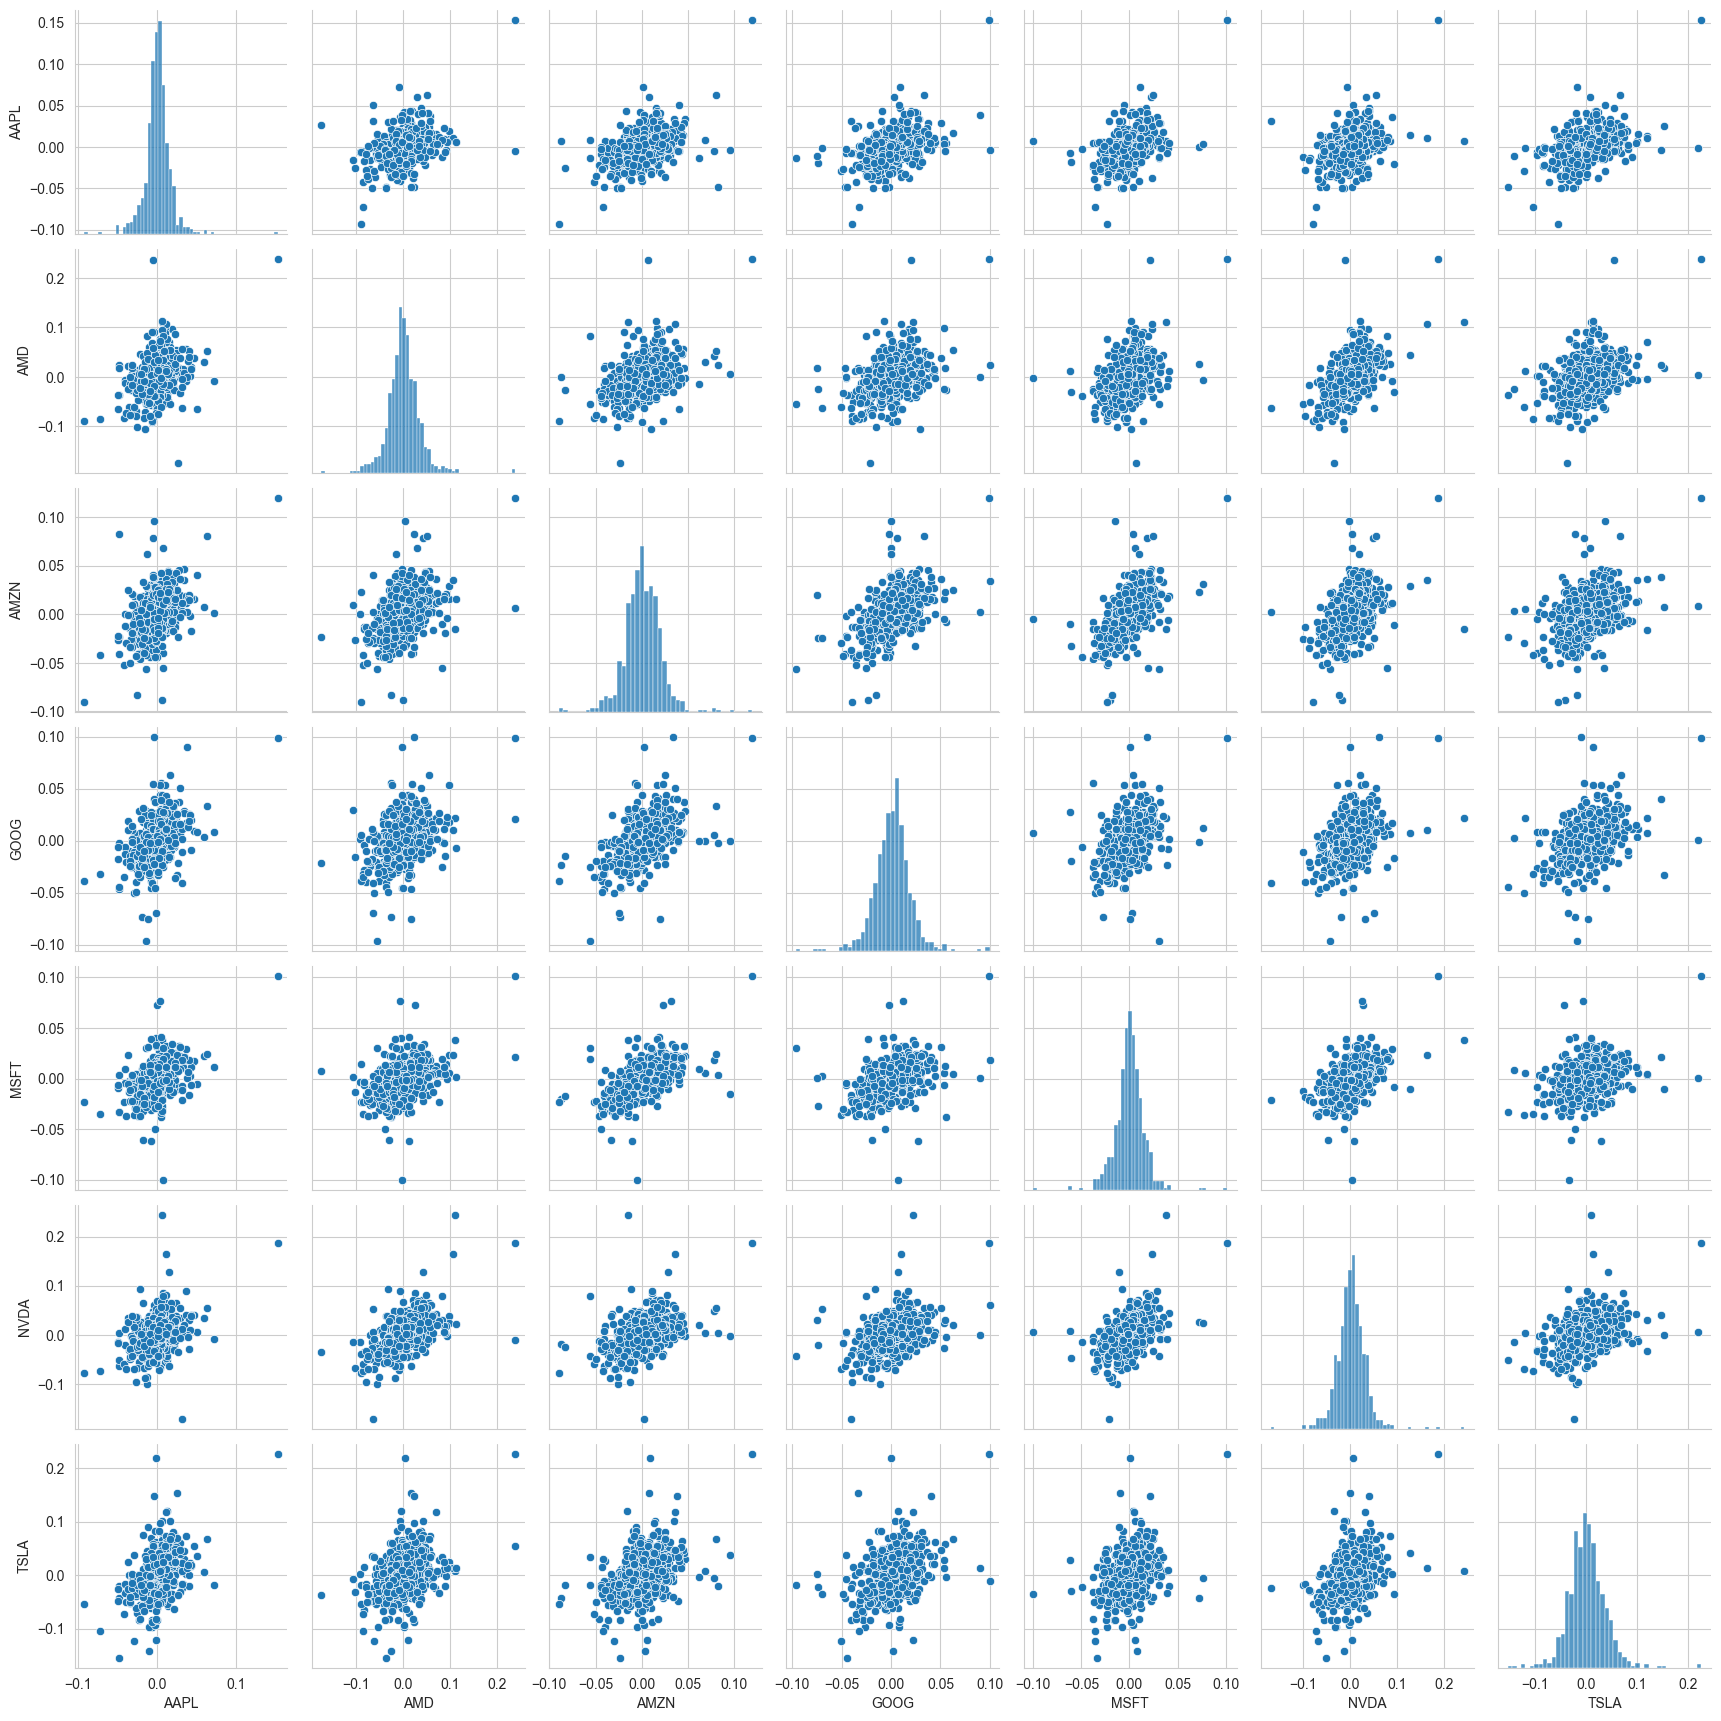

In [37]:
sns.pairplot(tech_rets.dropna())